# RLVR Results Visualization

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configure matplotlib
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

## Load and Preprocess Data

In [2]:
# Load the CSV file
csv_path = 'wandb_export_2026-01-26T21_33_57.237-08_00.csv'
df = pd.read_csv(csv_path)

# Rename columns for easier access
df.columns = [
    'step',
    'baseline_mean', 'baseline_min', 'baseline_max',
    'streaming_mean', 'streaming_min', 'streaming_max'
]

# Drop rows with missing values (last row has NaN for streaming)
df = df.dropna()

print(f"Loaded {len(df)} data points")
print(f"Step range: {df['step'].min()} to {df['step'].max()}")
df.head()

Loaded 58 data points
Step range: 0 to 171


,step,baseline_mean,baseline_min,baseline_max,streaming_mean,streaming_min,streaming_max
0,0,0.530012,0.525210,0.532413,0.531092,0.530212,0.532213
1,3,0.543978,0.541417,0.547819,0.544098,0.539016,0.549420
2,6,0.558263,0.553421,0.560824,0.574830,0.571028,0.583633
3,9,0.580112,0.574230,0.584234,0.599600,0.594038,0.611845
4,12,0.591837,0.588035,0.600240,0.612605,0.602441,0.616447


## Apply Exponential Smoothing

In [3]:
def exponential_smoothing(values, alpha=0.3):
    """
    Apply exponential smoothing to a series of values.

    Args:
        values: Array of values to smooth
        alpha: Smoothing factor (0 < alpha <= 1)
               Higher alpha = less smoothing (more weight on recent values)
               Lower alpha = more smoothing (more weight on historical values)

    Returns:
        Smoothed values array
    """
    smoothed = np.zeros_like(values, dtype=float)
    smoothed[0] = values[0]

    for i in range(1, len(values)):
        smoothed[i] = alpha * values[i] + (1 - alpha) * smoothed[i-1]

    return smoothed


# Smoothing parameter
ALPHA = 0.3  # Adjust this for more/less smoothing

# Apply exponential smoothing to all accuracy columns
df['baseline_mean_smooth'] = exponential_smoothing(df['baseline_mean'].values, alpha=ALPHA)
df['baseline_min_smooth'] = exponential_smoothing(df['baseline_min'].values, alpha=ALPHA)
df['baseline_max_smooth'] = exponential_smoothing(df['baseline_max'].values, alpha=ALPHA)

df['streaming_mean_smooth'] = exponential_smoothing(df['streaming_mean'].values, alpha=ALPHA)
df['streaming_min_smooth'] = exponential_smoothing(df['streaming_min'].values, alpha=ALPHA)
df['streaming_max_smooth'] = exponential_smoothing(df['streaming_max'].values, alpha=ALPHA)

print(f"Applied exponential smoothing with alpha={ALPHA}")

Applied exponential smoothing with alpha=0.3


## Plot Accuracy vs Training Steps

Saved: ./figures/eval_accuracy.pdf


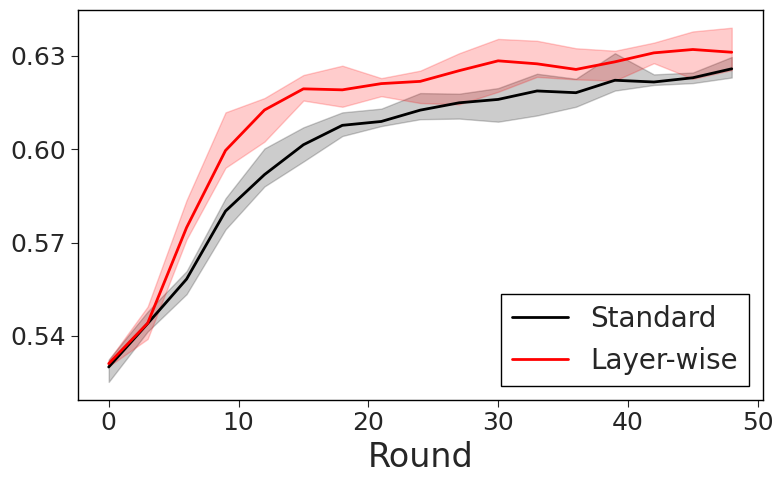

In [4]:
# Publication-ready plot: Original Accuracy vs Training Steps
# Using the same style as SFT and RLHF notebooks

# ============================================
# Plot Configuration
# ============================================
save_dir = './figures'  # Directory to save PDF figures
os.makedirs(save_dir, exist_ok=True)

# Step limit: set to None to plot all data, or specify a max step value
max_step = 50  # e.g., max_step = 100 to plot only steps 0-100

# Filter data by step limit
plot_df = df[df['step'] <= max_step] if max_step is not None else df

# Consistent color palette (same across all experiments)
# Standard: black, Gradient Streaming: red
METHOD_COLORS = {
    'baseline': 'black',
    'streaming': 'red',
}

LEGEND_NAMES = {
    'baseline': 'Standard',
    'streaming': 'Layer-wise',
}

# Create the publication-ready plot (original/raw data)
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

# Plot Baseline (Standard) - using original data
ax.plot(
    plot_df['step'],
    plot_df['baseline_mean'],
    linewidth=2,
    color=METHOD_COLORS['baseline'],
    label=LEGEND_NAMES['baseline']
)
ax.fill_between(
    plot_df['step'],
    plot_df['baseline_min'],
    plot_df['baseline_max'],
    color=METHOD_COLORS['baseline'],
    alpha=0.2
)

# Plot Streaming (Gradient Streaming) - using original data
ax.plot(
    plot_df['step'],
    plot_df['streaming_mean'],
    linewidth=2,
    color=METHOD_COLORS['streaming'],
    label=LEGEND_NAMES['streaming']
)
ax.fill_between(
    plot_df['step'],
    plot_df['streaming_min'],
    plot_df['streaming_max'],
    color=METHOD_COLORS['streaming'],
    alpha=0.2
)

# Formatting
ax.set_xlabel('Round', fontsize=24)
# ax.set_ylabel('Accuracy', fontsize=24)

# Light grid lines
ax.grid(True, alpha=0.3, linewidth=0.5)

# Clean style: all spines visible (outer frame)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_color('black')

# Sparse ticks with larger font
ax.tick_params(axis='both', which='major', labelsize=18, direction='out', length=5)
ax.xaxis.set_major_locator(plt.MaxNLocator(6))  # Sparse x ticks
ax.yaxis.set_major_locator(plt.MaxNLocator(5))  # Sparse y ticks

# Legend with pure white background
legend = ax.legend(loc='lower right', fontsize=20, frameon=True,
                  edgecolor='black', fancybox=False, framealpha=1.0)
legend.get_frame().set_facecolor('white')

plt.tight_layout()

# Save figure as PDF
filepath = os.path.join(save_dir, 'eval_accuracy.pdf')
fig.savefig(filepath, format='pdf', bbox_inches='tight', facecolor='white')
print(f"Saved: {filepath}")

plt.show()

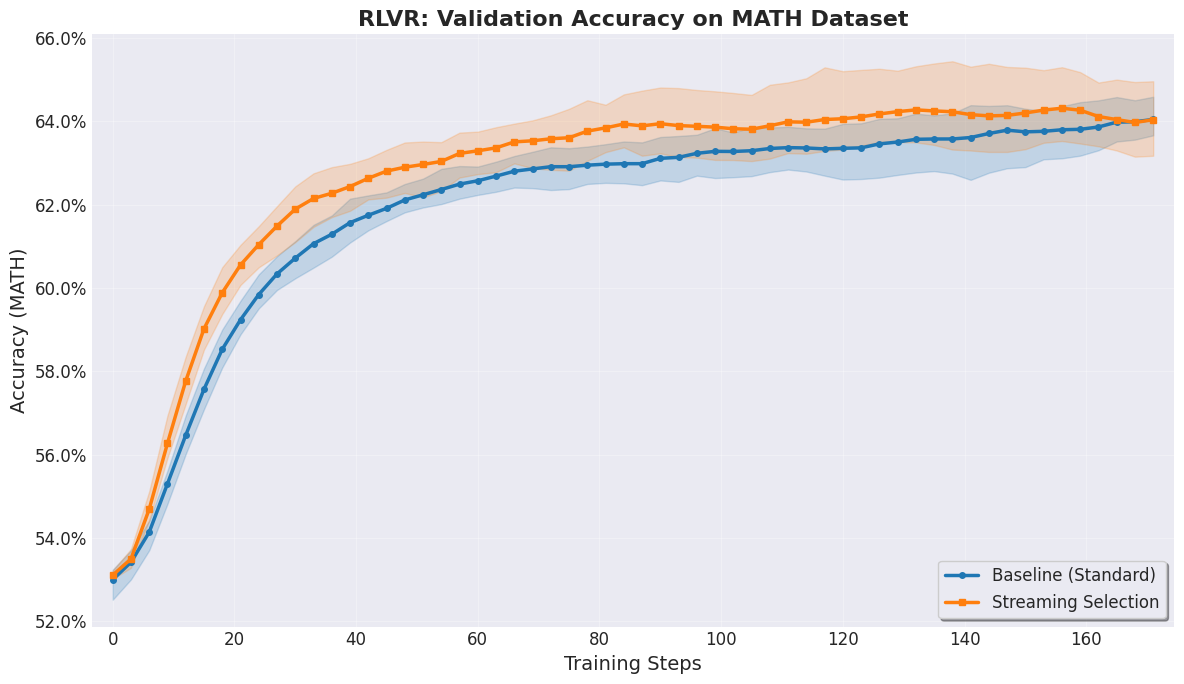

In [5]:
# Create the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Define colors
baseline_color = '#1f77b4'  # Blue
streaming_color = '#ff7f0e'  # Orange

# Plot Baseline (selection disabled)
ax.plot(
    df['step'],
    df['baseline_mean_smooth'],
    linewidth=2.5,
    marker='o',
    markersize=4,
    color=baseline_color,
    label='Baseline (Standard)'
)
ax.fill_between(
    df['step'],
    df['baseline_min_smooth'],
    df['baseline_max_smooth'],
    color=baseline_color,
    alpha=0.2
)

# Plot Streaming (selection enabled)
ax.plot(
    df['step'],
    df['streaming_mean_smooth'],
    linewidth=2.5,
    marker='s',
    markersize=4,
    color=streaming_color,
    label='Streaming Selection'
)
ax.fill_between(
    df['step'],
    df['streaming_min_smooth'],
    df['streaming_max_smooth'],
    color=streaming_color,
    alpha=0.2
)

# Formatting
ax.set_xlabel('Training Steps', fontsize=14)
ax.set_ylabel('Accuracy (MATH)', fontsize=14)
ax.set_title('RLVR: Validation Accuracy on MATH Dataset', fontsize=16, fontweight='bold')
ax.legend(loc='lower right', fontsize=12, frameon=True, fancybox=True, shadow=True)
ax.grid(True, alpha=0.3)
ax.margins(x=0.02)

# Format y-axis as percentage
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.1f}%'))

plt.tight_layout()
plt.show()

## Final Performance Comparison

In [6]:
# Print final results comparison
print("="*70)
print("Final Accuracy Results (at last step)")
print("="*70)

last_row = df.iloc[-1]

print(f"{'Method':<25} {'Mean Accuracy':<20} {'Min-Max Range'}")
print("-"*70)

# Baseline results
baseline_mean = last_row['baseline_mean_smooth']
baseline_min = last_row['baseline_min_smooth']
baseline_max = last_row['baseline_max_smooth']
print(f"{'Baseline (Standard)':<25} {baseline_mean*100:.2f}%{'':<14} [{baseline_min*100:.2f}% - {baseline_max*100:.2f}%]")

# Streaming results
streaming_mean = last_row['streaming_mean_smooth']
streaming_min = last_row['streaming_min_smooth']
streaming_max = last_row['streaming_max_smooth']
print(f"{'Streaming Selection':<25} {streaming_mean*100:.2f}%{'':<14} [{streaming_min*100:.2f}% - {streaming_max*100:.2f}%]")

print("="*70)

# Calculate improvement
improvement = (streaming_mean - baseline_mean) / baseline_mean * 100
print(f"\nImprovement: {streaming_mean*100:.2f}% - {baseline_mean*100:.2f}% = {(streaming_mean - baseline_mean)*100:.2f}pp ({improvement:.1f}% relative)")

Final Accuracy Results (at last step)
Method                    Mean Accuracy        Min-Max Range
----------------------------------------------------------------------
Baseline (Standard)       64.05%               [63.66% - 64.59%]
Streaming Selection       64.04%               [63.17% - 64.96%]

Improvement: 64.04% - 64.05% = -0.01pp (-0.0% relative)


## Raw vs Smoothed Comparison

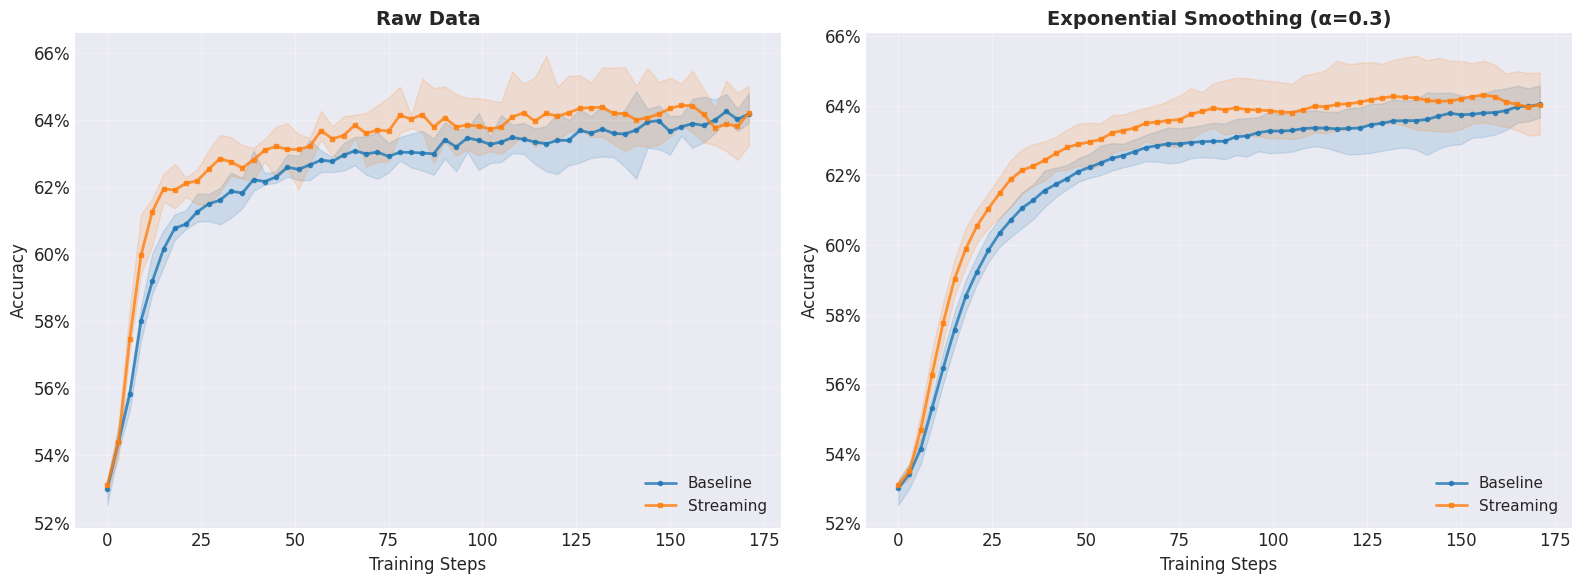

In [7]:
# Optional: Compare raw vs smoothed curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Raw data
ax = axes[0]
ax.plot(df['step'], df['baseline_mean'], linewidth=2, marker='o', markersize=3,
        color=baseline_color, label='Baseline', alpha=0.8)
ax.fill_between(df['step'], df['baseline_min'], df['baseline_max'],
                color=baseline_color, alpha=0.15)
ax.plot(df['step'], df['streaming_mean'], linewidth=2, marker='s', markersize=3,
        color=streaming_color, label='Streaming', alpha=0.8)
ax.fill_between(df['step'], df['streaming_min'], df['streaming_max'],
                color=streaming_color, alpha=0.15)
ax.set_xlabel('Training Steps', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Raw Data', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax.grid(True, alpha=0.3)

# Right plot: Smoothed data
ax = axes[1]
ax.plot(df['step'], df['baseline_mean_smooth'], linewidth=2, marker='o', markersize=3,
        color=baseline_color, label='Baseline', alpha=0.8)
ax.fill_between(df['step'], df['baseline_min_smooth'], df['baseline_max_smooth'],
                color=baseline_color, alpha=0.15)
ax.plot(df['step'], df['streaming_mean_smooth'], linewidth=2, marker='s', markersize=3,
        color=streaming_color, label='Streaming', alpha=0.8)
ax.fill_between(df['step'], df['streaming_min_smooth'], df['streaming_max_smooth'],
                color=streaming_color, alpha=0.15)
ax.set_xlabel('Training Steps', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title(f'Exponential Smoothing (α={ALPHA})', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()